# Monochrome camera calibration
One of the great disadvantages with using lenses is the distortion it introduces to the image. For vacation images, this is usually not a problem, but when we use the image to describe the physical surroundings it becomes important that the images are representative of the scene it captures. An easy way to get an indication of how distorted an image is by looking at what is supposed to be straight lines since they will appear curved. The following exercises you will be calibrating a camera to obtain a camera matrix such that you can undistort images from this camera.

In [1]:
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt

## Exercise 1
The process of calibrating an image consists of mainly 3 steps: 1) find chessboard-corners in a dataset of images containing a chessboard. 2) Use the corner points to compute a camera matrix. 3) Use the camera matrix to undistort images.

After setting some optimization parameters we can loop over all the images in the `imgs` folder and extract the checkerboard corners.

Use any of the images in the folder `imgs` to extract the number of checkerboard corners there are on the checkerboard. Fill in the information in `nb_vertical` and `nb_horizontal` and look up the opencv [findChessboardCorners](https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html#ga93efa9b0aa890de240ca32b11253dd4a) function and implement it in the below code snippet .

In [7]:
path = "C:/Users/peisz/OneDrive/Documents/Egyetem/DTU/3rd semester/PAS/Week 4/"

# Implement the number of vertical and horizontal corners
# Important: This refers to the *internal* corners where black and white squares touch, 
# not the number of squares themselves.
nb_vertical = 6
nb_horizontal = 7

# prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(6,5,0)
# These represent the coordinates of the corners in the real world.
# We assume the chessboard is fixed on the Z=0 plane, so Z is always 0.
# The points are just indices: (0,0), (0,1), (0,2)... which simplifies the math.
objp = np.zeros((nb_horizontal*nb_vertical,3), np.float32)
objp[:,:2] = np.mgrid[0:nb_vertical,0:nb_horizontal].T.reshape(-1,2)

# Arrays to store object points and image points from all the images.
objpoints = [] # 3d point in real world space (where the corners *should* be)
imgpoints = [] # 2d points in image plane (where the corners *are* in the photo)

images = glob.glob(path + 'imgs/*.png')
assert images

for fname in images:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Implement findChessboardCorners here
    # cv2.findChessboardCorners(image, patternSize, flags)
    # image: Source chessboard view. It must be an 8-bit grayscale or color image.
    # patternSize: Number of inner corners per a chessboard row and column (nb_vertical, nb_horizontal).
    # Returns: 
    # ret: Boolean (True if the pattern was found, False otherwise).
    # corners: Array of detected corner coordinates.
    ret, corners = cv2.findChessboardCorners(img, (nb_vertical,nb_horizontal), None)

    # If found, add object points, image points (after refining them)
    if ret == True:
        # We append the same 'objp' every time because the real-world board structure 
        # is the same for every photo, only the camera angle changes.
        objpoints.append(objp)

        # Append the detected 2D corners from the image
        # Note: In a production pipeline, you would typically use cv2.cornerSubPix() here
        # to refine the corner locations to sub-pixel accuracy before appending.
        imgpoints.append(corners)

        # Draw and display the corners
        # This visualizes the detection logic (draws colored lines connecting the corners)
        img = cv2.drawChessboardCorners(img, (nb_vertical,nb_horizontal), corners,ret)
        cv2.imshow('img',img)
        cv2.waitKey(500)

cv2.destroyAllWindows()

Using the extracted corners we can obtain a camera matrix that contains the information needed to undistort images

In [8]:
# cv2.calibrateCamera(objectPoints, imagePoints, imageSize, ...)
# This function solves for the camera intrinsic and extrinsic parameters.
# Returns:
# ret: The Root Mean Square (RMS) re-projection error. A lower value implies a better calibration (typically < 1.0 is good).
# mtx: Camera matrix (Intrinsic parameters). Contains focal lengths (fx, fy) and optical centers (cx, cy).
# dist: Distortion coefficients (k1, k2, p1, p2, k3). These model the radial and tangential distortion of the lens.
# rvecs, tvecs: Rotation and Translation vectors (Extrinsic parameters) for each image pattern view.
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)

img = cv2.imread(path + 'imgs/1403709067387836928.png')
h, w = img.shape[:2]

# cv2.getOptimalNewCameraMatrix(cameraMatrix, distCoeffs, imageSize, alpha, newImageSize)
# This function refines the camera matrix based on a free scaling parameter 'alpha'.
# alpha=1: All pixels are retained, but some black borders may be introduced (to fix the shape).
# alpha=0: The image is cropped to remove all black borders, but some valid pixels might be cut.
# Returns the new matrix and a Region of Interest (ROI) to crop the result.
newcameramtx, roi = cv2.getOptimalNewCameraMatrix(mtx,dist,(w,h),1,(w,h))

The last step is to actually undistort an image:

Text(0.5, 1.0, 'Undistorted image')

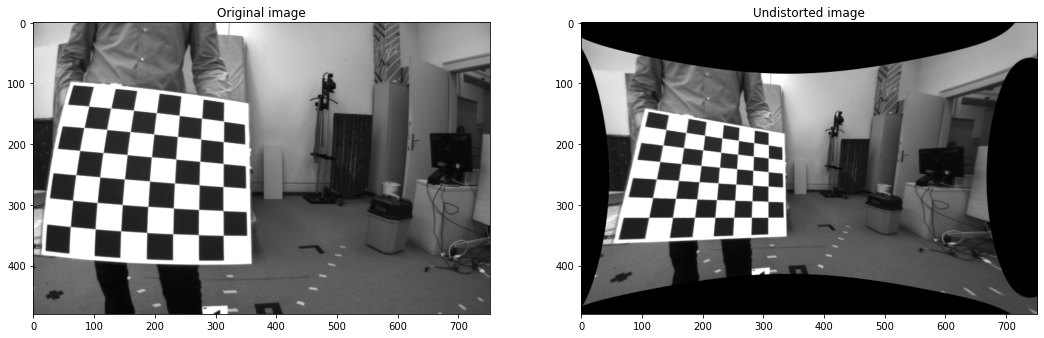

In [9]:
# undistort
# cv2.undistort(src, cameraMatrix, distCoeffs, dst, newCameraMatrix)
# Takes the original image, the calculated parameters (mtx, dist), and the refined matrix (newcameramtx)
# to map pixels to their correct, rectilinear positions.
dst = cv2.undistort(img, mtx, dist, None, newcameramtx)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,18))
# Matplotlib expects RGB, OpenCV provides BGR. We swap channels using [...,[2,1,0]]
ax[0].imshow(img[...,[2,1,0]])
ax[0].set_title('Original image')
ax[1].imshow(dst[...,[2,1,0]])
ax[1].set_title('Undistorted image')

A refining step can be to crop the image such that it doesn't contain the large black areas at the edges of the image.

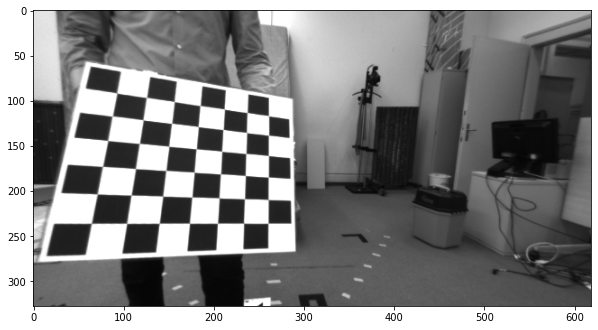

In [10]:
# crop the image using the ROI (Region of Interest) returned by getOptimalNewCameraMatrix
x,y,w,h = roi
dst = dst[y:y+h, x:x+w]
plt.figure(figsize=(10,10))
plt.imshow(dst[...,[2,1,0]])